A try to model the birth year coefficient across all ages, for 1 ROI that I suspect that changes in a non-linear way. 
ROI = 421 (amygdala)
ROI = putamen (or any other ROI that changes like a sinus)

In [1]:
import statsmodels.formula.api as smf
import pandas as pd          
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')
print(combined_df.columns)

combined_df['age_in_years'] = pd.to_numeric(combined_df['age_in_years'], errors='coerce')

Index(['subject_id', 'session_id', 'region_label', 'tissue_type', 'volume_mm3',
       'tiv', 'sex', 'institute', 'manufacturer', 'age_in_years', 'dob',
       'gm_volume_cm3', 'protocol', 'source', 'birth_year', 'Unnamed: 0',
       'atlas_name', 'scan_time', 'age_at_scan', 'weight', 'directory_path',
       'estimated_critical_info', 'scan_date', 'file_path',
       'classification_label'],
      dtype='object')


In [3]:
# all rois 1 to 454
df = combined_df[(combined_df['tissue_type'] == 'gm_volume_mm3') & (combined_df['tiv'] >= 1000)].copy()

# specific roi
# roi = []
# df = combined_df[(combined_df['region_label'].isin(roi)) & (combined_df['tissue_type'] == 'gm_volume_mm3') & (combined_df['tiv'] >= 1000)].copy() # 

# keep only the relevant columns
df = df[['age_in_years', 'volume_mm3', 'sex', 'tiv', 'birth_year', 'subject_id', 'region_label']]

df.to_csv(f"/home/gaia/Projects/legacy_data/data_for_r_all_rois.csv", index=False)


In [4]:
# GAM or GAMM?

# subject data
subject_df = combined_df[['subject_id', 'session_id']].drop_duplicates()

# if there's "sub-" at the start of subject_id, remove it
subject_df['subject_id'] = subject_df['subject_id'].str.replace('sub-', '', regex=False)

# Count scans per subject
scan_counts = subject_df['subject_id'].value_counts()
multi_scan_subjects = (scan_counts > 1).sum()
total_subjects = subject_df['subject_id'].nunique()

print(f"Total Unique Subjects: {total_subjects}")
print(f"Subjects with >1 scan: {multi_scan_subjects} ({multi_scan_subjects/total_subjects:.1%})")


Total Unique Subjects: 3708
Subjects with >1 scan: 936 (25.2%)


In [5]:
# # is tiv fixed or random within clusters (subject_id)? 

# # for each subject with more than 1 scan, list all tiv
# multi_scan_subjects = combined_df['subject_id'].value_counts()
# multi_scan_subjects = multi_scan_subjects[multi_scan_subjects > 1].index

# for subject in multi_scan_subjects:
#     tivs = combined_df[combined_df['subject_id'] == subject]['tiv'].unique()
#     print(f"Subject {subject} has TIVs: {tivs}")

# GAM

In [6]:
# from pygam import LinearGAM, s, f

# # x as float
# df['age_in_years'] = df['age_in_years'].astype(float)
# df['birth_year'] = df['birth_year'].astype(float)
# df['tiv'] = df['tiv'].astype(float)
# df['sex'] = df['sex'].astype('category').cat.codes  # Convert categorical

# # drop rows with missing values
# df = df.dropna()

# # 1. Prepare your data (assuming a DataFrame 'df')
# # X: Predictors (Age, BirthYear, Sex, TIV)
# # y: Target (Grey Matter Volume)
# feature_names = ['birth_year', 'age_in_years', 'sex', 'tiv']
# X = df[feature_names].values
# y = df['volume_mm3'].values

# # 2. Define the model
# # s() = smooth term (for continuous variables like Age, BirthYear, TIV)
# # f() = factor term (for categorical variables like Sex)
# gam = LinearGAM(s(0) + s(1) + f(2) + s(3)).gridsearch(X, y)

# # 3. Check the statistics
# print(gam.summary())

In [7]:
# # --- Visualization ---
# # We focus on the first two terms: Birth Year and Age
# fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# for i, ax in enumerate(axs):
#     # generate_X_grid creates a range of values for the term 'i' 
#     # while keeping other variables at their mean/mode
#     XX = gam.generate_X_grid(term=i)
#     pdep, confi = gam.partial_dependence(term=i, width=.95)
    
#     ax.plot(XX[:, i], pdep, color='darkblue', lw=2)
#     ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1], color='blue', alpha=0.1)
    
#     # Use our feature_names list to set correct titles
#     ax.set_title(f'Partial Effect of {feature_names[i]}', fontsize=14)
#     ax.set_xlabel(feature_names[i])
#     ax.set_ylabel('Effect on Volume (mm³)')
#     ax.grid(True, ls='--', alpha=0.6)

# plt.tight_layout()
# plt.show()

# GAMM

Run the R script GAMM.R
Then load the results - 
* all_effects: the components of the GAMM, estimations, std., statistic, p value
fixed effect (linear) - includes birth_year, sex, intercept
                        estimate is beta coef
                        statistic is t value
smooth effect (non-linear) - includes age_in_years, tiv
                        estimate is EDF (Estimated Degrees of Freedom). It describes the complexity of the curve. 1=linear, >1=non-linear, >5 highly complex
                        statistic is F value

* all_roi_curves : fit and se per roi 

In [8]:
# birth year is smoothed
all_effects = pd.read_csv("/home/gaia/all_effects.csv")
all_roi_curves = pd.read_csv("/home/gaia/all_roi_curves.csv")

all_roi_curves.rename(columns={'s(age_in_years)': 'age', 's(birth_year)': 'birth_year'}, inplace=True)

### sanity test for the differences in parameters between rois

In [9]:

# group all_roi_curves by roi 
roi1 = all_roi_curves[all_roi_curves['roi'] == 421]
roi2 = all_roi_curves[all_roi_curves['roi'] == 280]

# remove the index and roi columns in each 
roi1 = roi1.drop(columns=['roi'])
roi2 = roi2.drop(columns=['roi'])

# reset the index
roi1 = roi1.reset_index(drop=True)
roi2 = roi2.reset_index(drop=True)

# is roi1 == roi2? 
print(roi1.equals(roi2))

False


### Multiple comparison correction

In [14]:
import pandas as pd
from statsmodels.stats.multitest import multipletests

# 1. Load your results
df_results = all_effects

# 2. Filter for a specific term you want to test (e.g., the Age smooth)
mask = (df_results['term'] == 's(birth_year)')
age_pvals = df_results.loc[mask, 'PValue']

# 3. Apply FDR (Benjamini-Hochberg)
significant, p_corrected, _, _ = multipletests(age_pvals, alpha=0.05, method='fdr_bh')

# 4. Add the results back to your dataframe
df_results.loc[mask, 'PValue_FDR'] = p_corrected
df_results.loc[mask, 'is_significant_FDR'] = significant

# Count how many ROIs survived
print(f"Significant ROIs after FDR: {significant.sum()}")

significant_rois = df_results.loc[mask & df_results['is_significant_FDR'], 'roi']

# 5. Extract the estimates for the significant ROIs

filtered_df = df_results[
    (df_results['roi'].isin(significant_rois)) & 
    (df_results['term'].isin(['s(birth_year)', 's(age_in_years)']))
]

# 2. Pivot the data so 'roi' is the index and 'term' values become columns
estimates_of_significant_rois = filtered_df.pivot(
    index='roi', 
    columns='term', 
    values='Estimate'
).reset_index()

estimates_of_significant_rois.rename(columns={'s(age_in_years)': 'age', 's(birth_year)': 'birth_year'}, inplace=True)


Significant ROIs after FDR: 410


In [15]:
print(df_results.columns)
print(df_results['term'].unique())

Index(['term', 'effect_type', 'Estimate', 'StdError', 'Statistic', 'PValue',
       'roi', 'PValue_FDR', 'is_significant_FDR'],
      dtype='object')
['(Intercept)' 'tiv' 'sexM' 's(age_in_years)' 's(birth_year)']


Visualization

Mapping 410 ROI estimates to atlas...


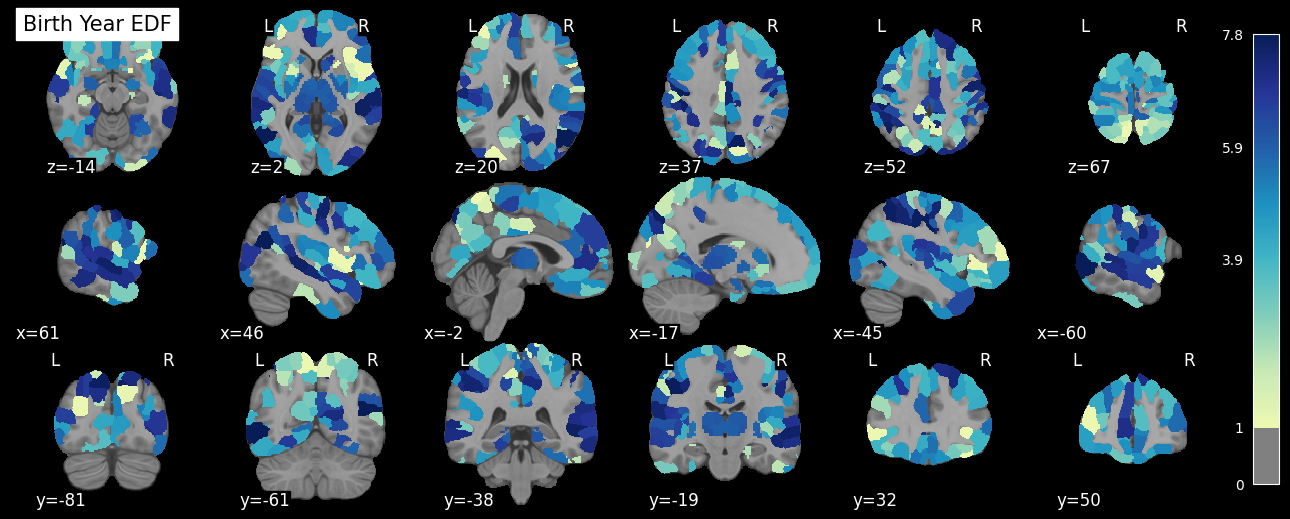

In [16]:
# for significant rois (is_significant_FDR == True), plot on the brain. color code by estimate (1=linear, 1-5=non-linear)

import numpy as np
import nibabel as nib
from nilearn import plotting
from nilearn.image import new_img_like
from nilearn.datasets import load_mni152_template

# --- 1. Load Your Atlas ---
atlas_file_path = '/media/storage/MATLAB_atlases-20250612T134418Z-1-001/MATLAB_atlases/schaefer2018tian2020_400_7.nii'
atlas_img = nib.load(atlas_file_path)
atlas_labels = atlas_img.get_fdata()

# --- 2. Map Estimates from result_df ---
# We create a dictionary mapping the ROI label to the Birth Year estimate
# We assume 'roi' contains the numeric label that matches the atlas voxels
birth_year_map = dict(zip(estimates_of_significant_rois['roi'], estimates_of_significant_rois['birth_year']))

# --- 3. Create the statistical map ---
# Initialize with zeros
stat_map_data = np.zeros_like(atlas_labels, dtype=float)

print(f"Mapping {len(birth_year_map)} ROI estimates to atlas...")

for label, estimate in birth_year_map.items():
    # Only map if the estimate is not NaN
    if pd.notnull(estimate):
        # Important: Ensure label is cast to int if it's stored as a string or float
        stat_map_data[atlas_labels == int(label)] = estimate

# Create the NIfTI image
birth_year_map_img = new_img_like(atlas_img, stat_map_data)

# --- 4. Plotting ---
bg_img = load_mni152_template()

# Note: I removed threshold=1 because estimates (coefficients) are often 
# smaller than T-statistics. If your plot is empty, lower the threshold.
plotting.plot_stat_map(
    stat_map_img=birth_year_map_img,
    bg_img=bg_img,
    title="Birth Year EDF",
    cmap='YlGnBu',
    symmetric_cbar=False,
    threshold=1, # Set very low to see all significant effects
    display_mode='mosaic',
    cut_coords=(6, 6, 6),
    colorbar=True
)

plotting.show()

In [19]:
# plot the data with prediction
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_roi_trajectory(roi_name, variable):
    data = all_roi_curves[all_roi_curves['roi'] == roi_name]
    
    plt.figure(figsize=(10, 6))
    
    # Plot the main curve
    sns.lineplot(data=data, x=variable, y='fit', color='blue', label='Predicted Volume')
    
    # Add Confidence Intervals (Fit +/- 1.96 * SE)
    plt.fill_between(data[variable], 
                     data['fit'] - 1.96 * data['se'], 
                     data['fit'] + 1.96 * data['se'], 
                     alpha=0.2, color='blue', label='95% CI')
    
    # add the mean volume as a dotted line 
    mean_volume = data['fit'].mean()
    plt.axhline(mean_volume, color='blue', linestyle='dotted', label='Mean Volume')

    plt.title(f'Aging Trajectory for {roi_name}')
    plt.xlabel(variable)
    plt.ylabel('Volume (mm³)')
    plt.legend()
    plt.show()

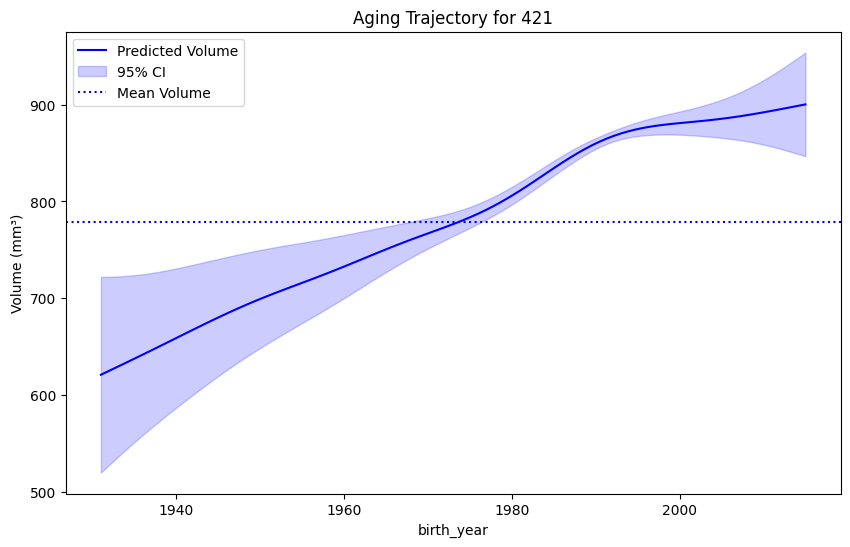

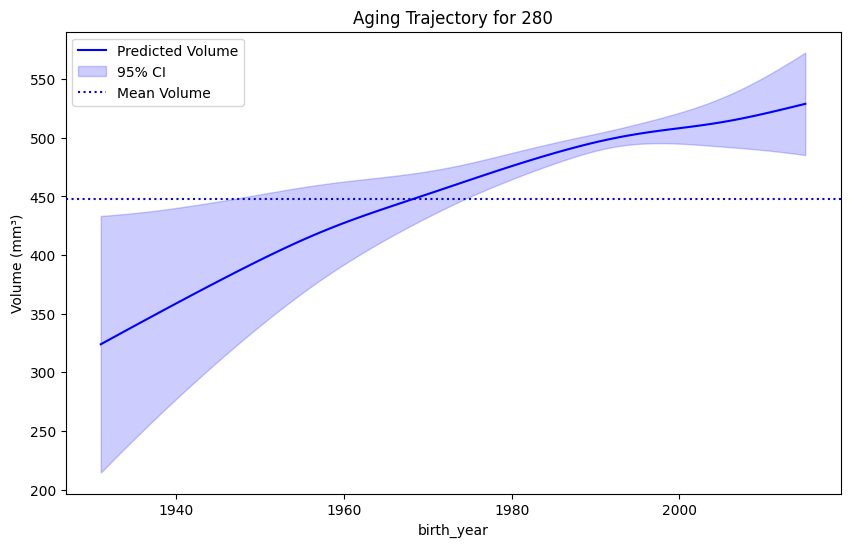

In [20]:
# for roi in estimates_of_significant_rois['roi']:
#     plot_roi_trajectory(roi, 'birth_year')

plot_roi_trajectory(421, 'birth_year')
plot_roi_trajectory(280, 'birth_year')